# Filtri

## Filtriranje z FIR

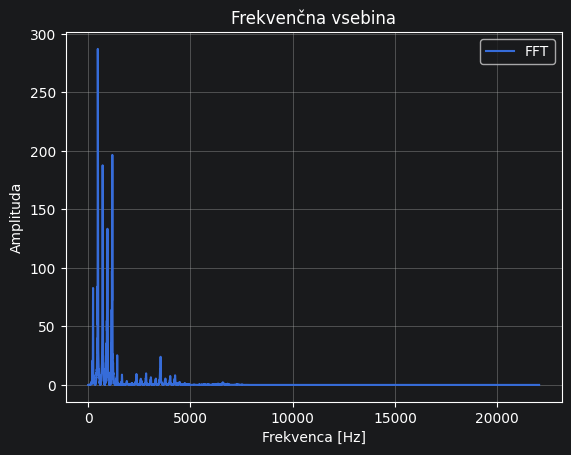

Frequencies to filter: [ 237.33692119  705.34399613  941.34756383 1180.01783852 1418.6881132 ]


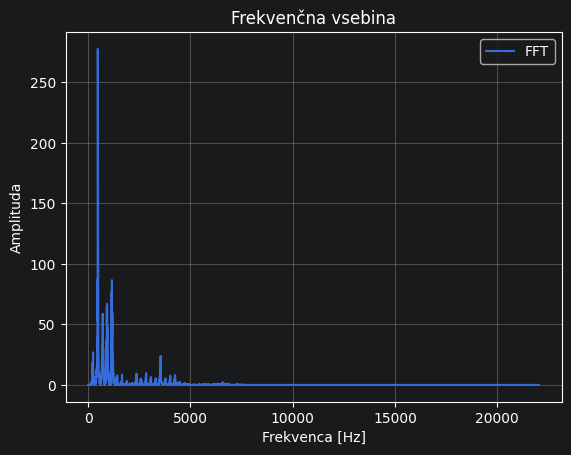

In [84]:
import util, filter
from importlib import reload

reload(util)
reload(filter)

from filter import *
from util import *


file_name = "a_high_pitch.mp3"
fo = 2001

y, Fs = read_signal_from_mp3(fr"recordings/{file_name}")

y_fft = np.fft.fft(y)
plot_fft(y_fft, Fs)

harmonics = find_harmonics(y_fft, Fs, prominence=(50, None), distance=150)

y_fil = design_fir(y, harmonics, Fs, fo)
y_fil_fft = np.fft.fft(y_fil)
plot_fft(y_fil_fft, Fs)


## Filtriranje s IIR

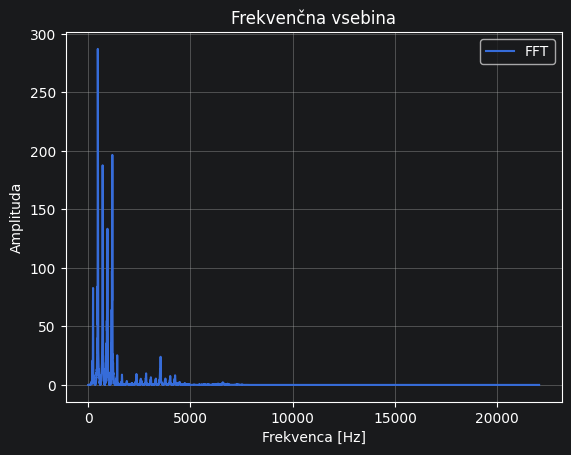

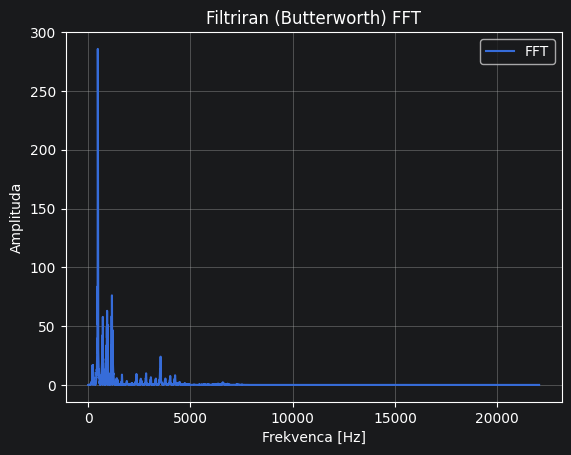

In [85]:
file_name = "a_high_pitch.mp3"
y, Fs = read_signal_from_mp3(fr"recordings/{file_name}")

y_fft = np.fft.fft(y)
plot_fft(y_fft, Fs)

harmonics= find_harmonics(y_fft, Fs, prominence=(50, None), distance=150)

# Butterworth
fo = 1
y_fil = design_iir(y, harmonics, Fs, fo)
y_fil_fft = np.fft.fft(y_fil)
plot_fft(y_fil_fft, Fs, label="Filtriran (Butterworth) FFT")

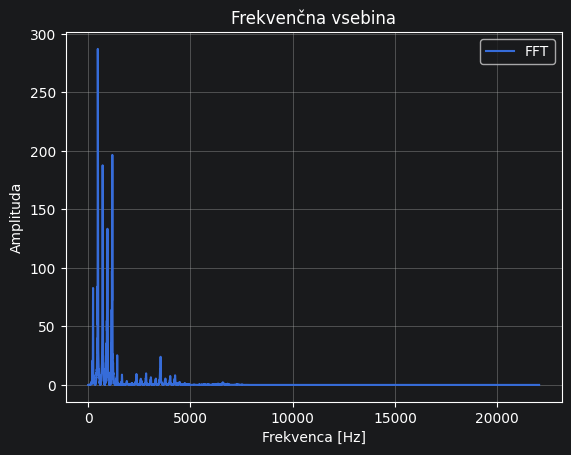

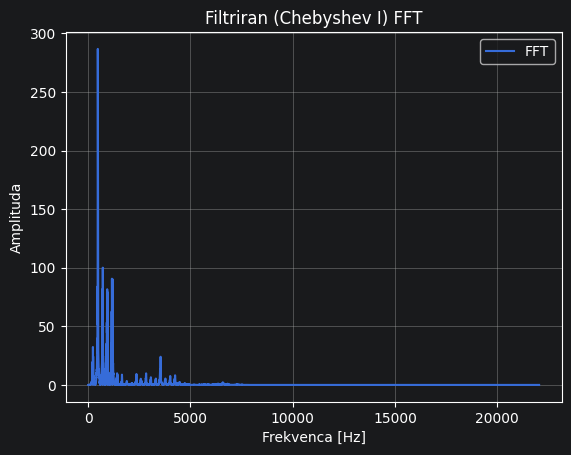

In [86]:
# Chebyshev I
plot_fft(y_fft, Fs)
y_fil = design_iir(y, harmonics, Fs, fo, filter_type=Filter.CHEBYSHEV_I)
y_fil_fft = np.fft.fft(y_fil)
plot_fft(y_fil_fft, Fs, label="Filtriran (Chebyshev I) FFT")

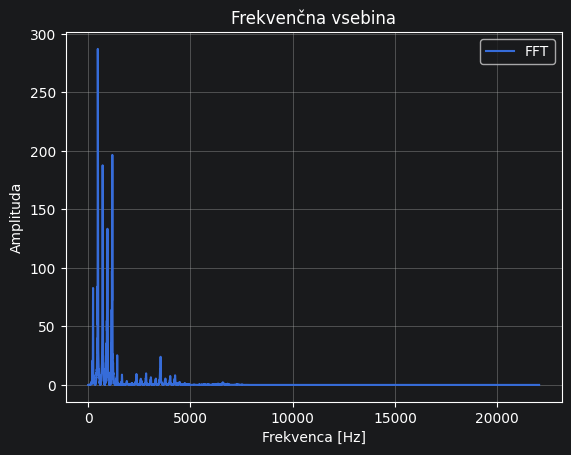

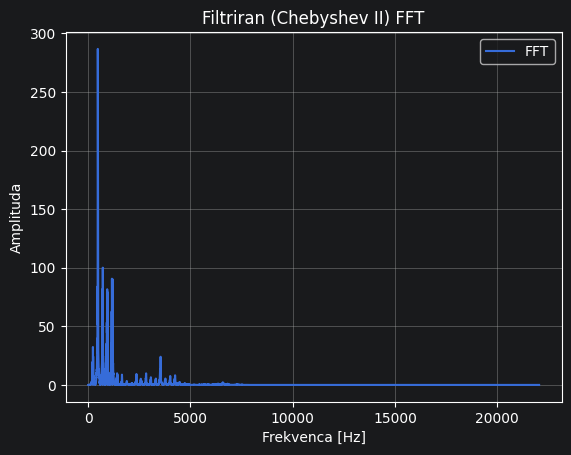

In [87]:
# Chebyshev II
plot_fft(y_fft, Fs)
y_fil = design_iir(y, harmonics, Fs, fo, filter_type=Filter.CHEBYSHEV_II)
y_fil_fft = np.fft.fft(y_fil)
plot_fft(y_fil_fft, Fs, label="Filtriran (Chebyshev II) FFT")

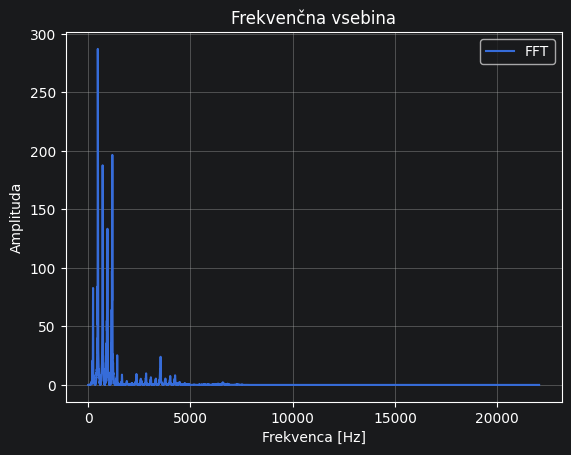

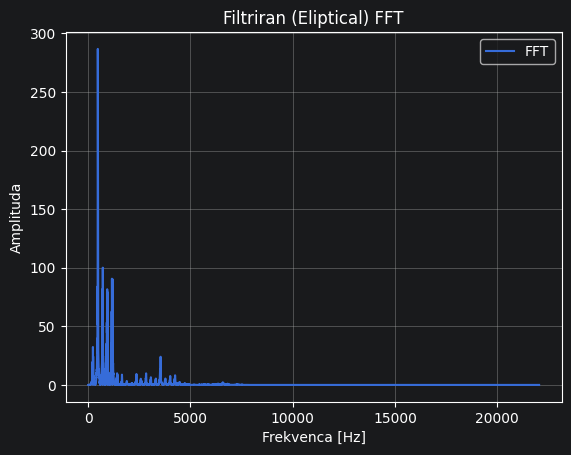

In [88]:
# Eliptical
plot_fft(y_fft, Fs)
y_fil = design_iir(y, harmonics, Fs, fo, filter_type=Filter.ELIPTICAL)
y_fil_fft = np.fft.fft(y_fil)
plot_fft(y_fil_fft, Fs, label="Filtriran (Eliptical) FFT")